# Model 4 - LightGBM
**Owner:** _(your name)_  |  **Branch:** `model/lightgbm`  |  **Stage 6 + 7** - model development, comparison and optimisation

Fast gradient boosting with leaf-wise tree growth. Efficient on large, sparse, high-cardinality data like this one.

> **How to run:** first set `DATA_FRAC = 0.1` to check that everything works (a few minutes), then set it to `1.0` and *Run All* for the real results.
> Everything here uses the shared code in `src/` - same split, same 5 folds, same metrics as the other members.

LightGBM builds many decision trees one after another. Each new tree tries to correct errors made by the previous trees.
This is called boosting.
I used LightGBM as a classification model because it works efficiently on large tabular datasets, can learn complex patterns, and supports class weighting for our imbalanced classes.

## 1. Setup and data

In [5]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
from common import *
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectFromModel

NAME = "LightGBM"

# ---- run configuration ---------------------------------------------------------------------------
DATA_FRAC        = 1.0    # share of TRAINING patients used in this notebook (0.1 = quick check run)
EXP_FRAC         = 0.3    # share of patients used for the small experiments in section 4
TUNE_SAMPLE_FRAC = 0.3    # share of patients used DURING the search for best hyperparameters (0.1 = quick check run)
N_ITER           = 20     # Try 20 different combinations during tuning
SEARCH_METHOD    = "random"   # "random" | "grid" | "halving"
# --------------------------------------------------------------------------------------------------
reset_log(NAME)

In [6]:
X_train, X_test, y_train, y_test, g_train, cv, class_names = load_and_split()
X_train, y_train, g_train = patient_subsample(X_train, y_train, g_train, DATA_FRAC)
X_exp, y_exp, g_exp = patient_subsample(X_train, y_train, g_train, EXP_FRAC)
print("train", X_train.shape, "| test", X_test.shape, "| classes", class_names)
pd.Series(y_train).map(dict(enumerate(class_names))).value_counts(normalize=True).round(3)

train (79541, 50) | test (19802, 50) | classes ['<30', '>30', 'NO']


NO     0.528
>30    0.357
<30    0.114
Name: proportion, dtype: float64

## 2. Why this model? (algorithm selection and justification)

- **Task fit:** multiclass with probabilities, supports `class_weight="balanced"` directly.
- **Data fit:** histogram-based and leaf-wise growth make it much faster than XGBoost on ~80k rows x 2,400 sparse columns; regularised by `min_child_samples`, `num_leaves` and subsampling. **Weaknesses:** leaf-wise trees over-fit small data if `num_leaves` is too large.
- **Role in the project:** a second boosting model - comparing it with XGBoost shows how much the tree-growth strategy matters.

## 3. Baseline model and validation strategy
- **Validation:** 5-fold `StratifiedGroupKFold` on the training set, grouped by `patient_nbr` (a patient never appears in both the training and validation part of a fold) and stratified (the rare `<30` class, about 11%, appears in every fold). The folds are fixed (`random_state=42`) and identical for every model.
- **Preprocessing inside the pipeline:** imputation, scaling and one-hot encoding are refitted on the training part of each fold, so nothing leaks from the validation part.
- **Imbalance:** handled with class weights, not by resampling (SMOTE works poorly on ~2,400 sparse one-hot columns).
- **Main metric: macro-F1** (every class counts equally). Accuracy is misleading here because always predicting `NO` already scores about 55%. We also track macro-recall, ROC-AUC (one-vs-rest) and PR-AUC / recall for the `<30` class.
- The **test set is not touched** until section 6.

In [ ]:
#Build the baseline LightGBM model
def make_pipe(**kw):
    params = dict(n_estimators=300, learning_rate=0.1, num_leaves=31, class_weight="balanced",
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                  n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
    params.update(kw)
    return Pipeline([("pre", make_preprocessor(scale=False)),
                     ("m", LGBMClassifier(**params))])


pipe = make_pipe()
baseline = cv_evaluate(pipe, X_train, y_train, g_train, cv)
pd.Series({k: round(v, 4) for k, v in baseline.items() if not isinstance(v, list)})

cv_macro_f1           0.4514
cv_weighted_f1        0.5272
cv_macro_recall       0.4679
cv_macro_precision    0.4524
cv_accuracy           0.5128
cv_roc_auc_ovr        0.6656
cv_pr_auc_lt30        0.2193
cv_recall_lt30        0.3690
cv_precision_lt30     0.2075
cv_f1_lt30            0.2656
cv_macro_f1_std       0.0050
cv_pr_auc_lt30_std    0.0112
train_macro_f1        0.6151
fit_time_s            5.8065
dtype: float64

### Baseline observations
Train macro-F1 = 0.6151

CV macro-F1    = 0.4514

Training performance is much higher.
The model learned the training data better than unseen validation data.
so the model showed some overfitting.


## 4. Experiments - understanding why the model behaves the way it does
We already created the normal model.
Now we want to understand:
“What happens if we change different LightGBM settings?”
The experiments use only 30% of patients to run faster.

### Experiment 1
num_leaves -> It controls how complex a LightGBM tree can become.
More leaves -> more complex tree

[num_leaves] num_leaves=7: macro-F1=0.4359 (train 0.5054)
[num_leaves] num_leaves=15: macro-F1=0.4390 (train 0.5780)
[num_leaves] num_leaves=31: macro-F1=0.4480 (train 0.6889)
[num_leaves] num_leaves=63: macro-F1=0.4422 (train 0.8269)
[num_leaves] num_leaves=127: macro-F1=0.4379 (train 0.9505)


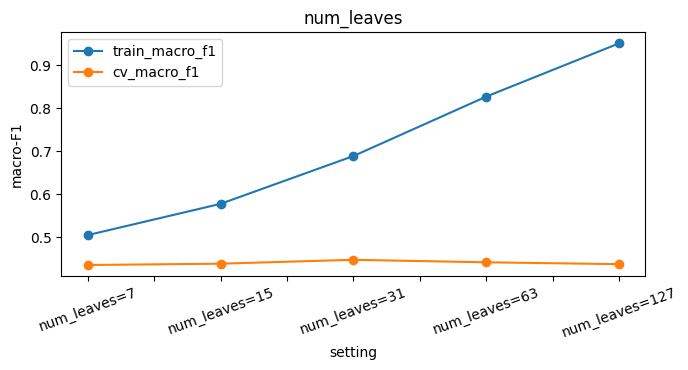

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,num_leaves,num_leaves=7,0.4359,0.5054,0.4562,0.6602,0.2052,1.1253
1,num_leaves,num_leaves=15,0.4390,0.5780,0.4549,0.6573,0.1973,1.1088
2,num_leaves,num_leaves=31,0.4480,0.6889,0.4567,0.6538,0.1933,1.7374
3,num_leaves,num_leaves=63,0.4422,0.8269,0.4440,0.6473,0.1835,2.3996
4,num_leaves,num_leaves=127,0.4379,0.9505,0.4367,0.6410,0.1759,3.8886


In [ ]:
sweep(NAME, "num_leaves", [7, 15, 31, 63, 127], lambda v: make_pipe(num_leaves=v, n_estimators=150), X_exp, y_exp, g_exp, cv)
#Test different num_leaves

**Observation:** Increasing num_leaves improved performance up to a point, but very large values increased training performance while reducing validation performance, showing overfitting.

### Experiment 2
Now you test:
min_child_samples-> Minimum number of records allowed in one leaf.



[min_child_samples] min_child_samples=5: macro-F1=0.4429 (train 0.7084)
[min_child_samples] min_child_samples=20: macro-F1=0.4480 (train 0.6889)
[min_child_samples] min_child_samples=50: macro-F1=0.4406 (train 0.6687)
[min_child_samples] min_child_samples=100: macro-F1=0.4405 (train 0.6471)
[min_child_samples] min_child_samples=200: macro-F1=0.4387 (train 0.6240)


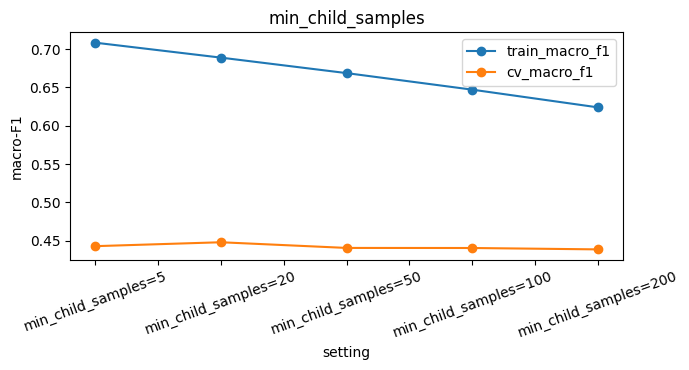

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,min_child_samples,min_child_samples=5,0.4429,0.7084,0.4515,0.6491,0.1907,1.8087
1,min_child_samples,min_child_samples=20,0.4480,0.6889,0.4567,0.6538,0.1933,1.4995
2,min_child_samples,min_child_samples=50,0.4406,0.6687,0.4500,0.6498,0.1858,1.4625
3,min_child_samples,min_child_samples=100,0.4405,0.6471,0.4514,0.6487,0.1836,1.5185
4,min_child_samples,min_child_samples=200,0.4387,0.6240,0.4510,0.6491,0.1855,1.5986


In [5]:
sweep(NAME, "min_child_samples", [5, 20, 50, 100, 200], lambda v: make_pipe(min_child_samples=v, n_estimators=150), X_exp, y_exp, g_exp, cv)

**Observation:** Very small values can overfit, while very large values can make the model too restricted and can underfit.A moderate value gave better validation performance

### Experiment 3
**Class imbalance handling** - balanced class weights vs none. Look at macro-F1, macro-recall and accuracy in the log.

In [6]:
for cw in ["balanced", None]:
    run_experiment(NAME, "Class weight", f"class_weight={cw}", make_pipe(class_weight=cw, n_estimators=150), X_exp, y_exp, g_exp, cv)
show_experiments(NAME, "Class weight")

[Class weight] class_weight=balanced: macro-F1=0.4480 (train 0.6889)
[Class weight] class_weight=None: macro-F1=0.4086 (train 0.5983)


,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Class weight,class_weight=balanced,0.4480,0.6889,0.4567,0.6538,0.1933,1.4752
1,Class weight,class_weight=None,0.4086,0.5983,0.4213,0.6621,0.1947,1.5203


**Observation:** Balanced class weights improved macro-F1 from 0.4086 to 0.4480, showing that imbalance handling was useful.

### Experiment 4
**Feature selection** - keep only the top-K features ranked by a LightGBM model (selected inside each fold, no leakage).
Do we really need all the features?
Keep the more useful features and remove less useful ones.


[Top-K features] Top-K features=50: macro-F1=0.4413 (train 0.6832)
[Top-K features] Top-K features=150: macro-F1=0.4415 (train 0.6821)
[Top-K features] Top-K features=400: macro-F1=0.4450 (train 0.6818)


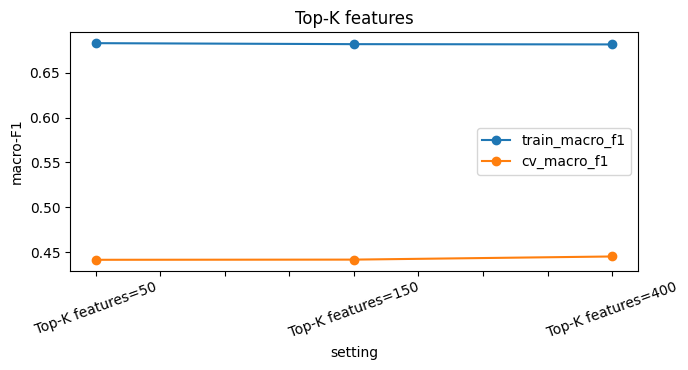

,experiment,setting,cv_macro_f1,train_macro_f1,cv_macro_recall,cv_roc_auc_ovr,cv_pr_auc_lt30,fit_time_s
0,Top-K features,Top-K features=50,0.4413,0.6832,0.4507,0.6465,0.1888,1.8236
1,Top-K features,Top-K features=150,0.4415,0.6821,0.4516,0.6501,0.1927,1.9524
2,Top-K features,Top-K features=400,0.4450,0.6818,0.4548,0.6522,0.1938,2.2548


In [7]:
def make_selected(k):
    selector = SelectFromModel(LGBMClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1,
                                              random_state=RANDOM_STATE, verbose=-1),
                               max_features=k, threshold=-np.inf)
    return Pipeline([("pre", make_preprocessor(scale=False)), ("sel", selector),
                     ("m", LGBMClassifier(n_estimators=150, learning_rate=0.1, num_leaves=31, class_weight="balanced",
                                          n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))])
sweep(NAME, "Top-K features", [50, 150, 400], make_selected, X_exp, y_exp, g_exp, cv)

**Observation:** Feature selection did not improve the model enough, so we kept the full feature set.

## 5. Hyper-parameter tuning (Stage 7)
Trying different model settings to find a better combination.

used Randomized Search to test 20 combinations of LightGBM settings using five-fold cross-validation and identify the best combination

In [8]:
space = {"m__num_leaves": [15, 31, 63],
         "m__learning_rate": [0.03, 0.05, 0.1],
         "m__n_estimators": [200, 400, 600],
         "m__min_child_samples": [20, 50, 100],
         "m__subsample": [0.7, 0.85, 1.0],
         "m__colsample_bytree": [0.6, 0.8, 1.0]}


tune_res = tune(pipe, space, X_train, y_train, g_train, cv,
                method=SEARCH_METHOD, n_iter=N_ITER, sample_frac=TUNE_SAMPLE_FRAC)
print("Best parameters:", tune_res.best_params_)
print(f"Search took {tune_res.search_time_s/60:.1f} min")
top_configs(tune_res)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'m__subsample': 0.7, 'm__num_leaves': 63, 'm__n_estimators': 200, 'm__min_child_samples': 50, 'm__learning_rate': 0.03, 'm__colsample_bytree': 0.6}
Search took 5.6 min


,param_m__subsample,param_m__num_leaves,param_m__n_estimators,param_m__min_child_samples,param_m__learning_rate,param_m__colsample_bytree,mean_test_score,std_test_score
17,0.70,63,200,50,0.03,0.6,0.4483,0.0031
5,1.00,31,600,20,0.03,0.8,0.4479,0.0036
3,0.85,31,200,50,0.05,0.8,0.4472,0.0057
9,0.70,15,600,20,0.05,0.8,0.4467,0.0054
15,1.00,31,200,20,0.05,0.6,0.4465,0.0024


In [ ]:
tuned = cv_evaluate(tune_res.best_estimator_, X_train, y_train, g_train, cv)   # full 5-fold CV, comparable with baseline
compare_table(baseline, tuned)
#Compare baseline vs tuned model

,baseline,tuned,change
CV macro-F1 (main metric),0.4514,0.4572,0.0058
CV macro-recall,0.4679,0.4783,0.0104
CV accuracy,0.5128,0.5164,0.0036
"CV ROC-AUC (OvR, macro)",0.6656,0.6743,0.0087
CV PR-AUC for <30,0.2193,0.2301,0.0108
CV recall for <30,0.3690,0.4082,0.0392
Train macro-F1 (over-fit check),0.6151,0.5435,-0.0716
Fit time per fold (s),5.1237,5.8389,0.7152


**Observation:** Tuning gave a small improvement in overall macro-F1, improved minority-class recall, and reduced overfitting.

## 6. Final evaluation on the untouched test set (reported once)
The final model of the project is chosen later, in `compare_models.ipynb`, by **CV score - not by test score**.
The test set is used only once at the end.

You do not select the best model using the test set.
Why?Because test data should stay unseen.
A
fter model development and tuning were finished, we used the untouched test set only for final evaluation.

              precision    recall  f1-score   support

         <30      0.207     0.413     0.276      2216
         >30      0.494     0.428     0.459      7090
          NO      0.683     0.602     0.640     10496

    accuracy                          0.518     19802
   macro avg      0.461     0.481     0.458     19802
weighted avg      0.562     0.518     0.534     19802



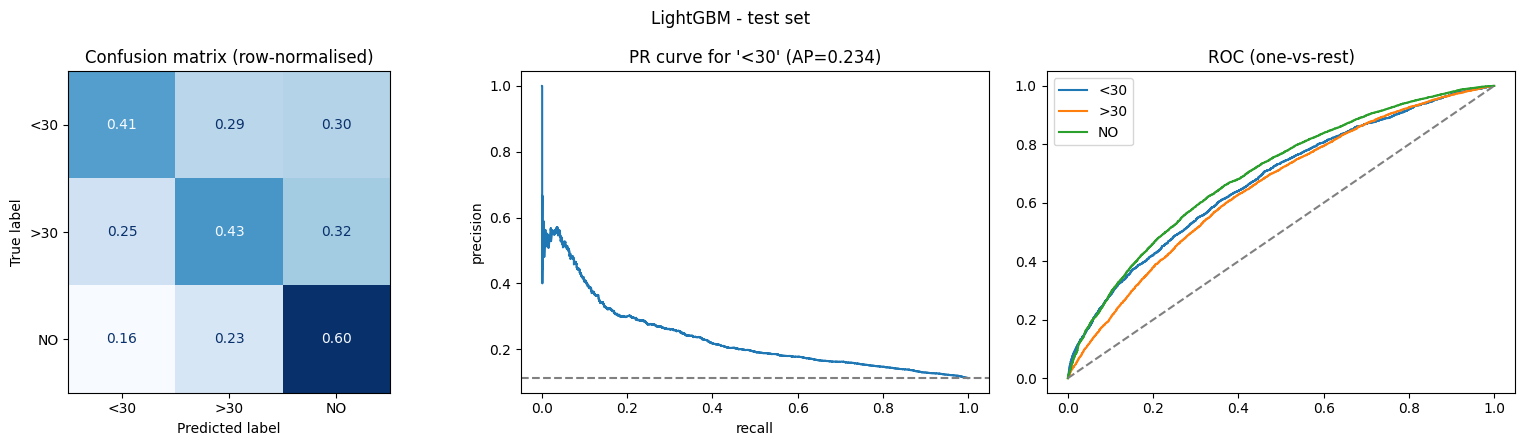

Saved outputs/results/lightgbm.json and outputs/models/lightgbm.joblib


In [10]:
result = finalize(NAME, baseline, tuned, tune_res, X_test, y_test, class_names)

## 7. Interpretation

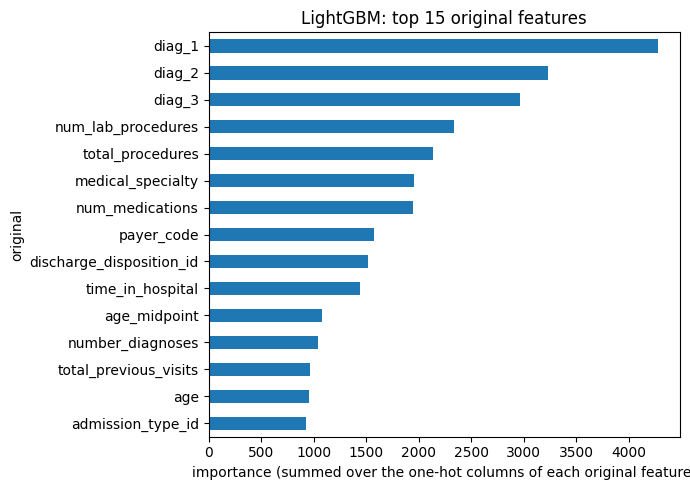

original
diag_1                      4275
diag_2                      3229
diag_3                      2961
num_lab_procedures          2336
total_procedures            2133
medical_specialty           1951
num_medications             1942
payer_code                  1576
discharge_disposition_id    1521
time_in_hospital            1445
age_midpoint                1077
number_diagnoses            1042
total_previous_visits        965
age                          959
admission_type_id            930
Name: value, dtype: int32

In [ ]:
best = tune_res.best_estimator_
tbl = feature_importance_table(best, X_train.columns)
top = top_original_features(tbl, 15)
plot_top_features(top, f"{NAME}: top 15 original features", NAME)
top.round(4)
#Feature importance

## 8. Observations and viva preparation
**Write your own conclusions here (they go into the report):**
- Where does this model perform well / badly, per class? Why?
- What did the experiments show about over-fitting, imbalance and feature choices?
- Do the important features make clinical sense?

**Be ready to answer:**

- Leaf-wise vs level-wise tree growth: why is LightGBM faster? What is `num_leaves`?
- What did the class-weight experiment show about accuracy vs macro-recall?
- What do `min_child_samples` and `subsample` do to prevent over-fitting?
- How does LightGBM compare with XGBoost on your results, and why?
- Did feature selection change the score?